# 02 — Exploratory Data Analysis
Understand the NEU-DET dataset before training: class balance, image samples, and bounding-box statistics.

Run `01_data_preparation.ipynb` first.

## 1. Setup

In [1]:
from pathlib import Path
import collections
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'data' / 'neu-det-yolo'
CLASSES = ['crazing','inclusion','patches','pitted_surface','rolled-in_scale','scratches']
assert OUT.exists(), 'Run 01_data_preparation.ipynb first!'
print('Dataset:', OUT)

Dataset: c:\Users\student\Desktop\SteelDefectDetection\data\neu-det-yolo


## 2. Class distribution
Count how many bounding boxes of each class appear in train + val.

In [2]:
def count_classes(label_dir):
    counts = collections.Counter()
    for txt in Path(label_dir).glob('*.txt'):
        for line in txt.read_text().splitlines():
            if line.strip():
                counts[int(line.split()[0])] += 1
    return counts

train_counts = count_classes(OUT / 'labels/train')
val_counts   = count_classes(OUT / 'labels/val')

print(f"{'class':<18}{'train':>8}{'val':>8}")
for i, name in enumerate(CLASSES):
    print(f'{name:<18}{train_counts[i]:>8}{val_counts[i]:>8}')

class                train     val
crazing                527      82
inclusion              852      87
patches                688     100
pitted_surface         345      41
rolled-in_scale        496      70
scratches              427      61


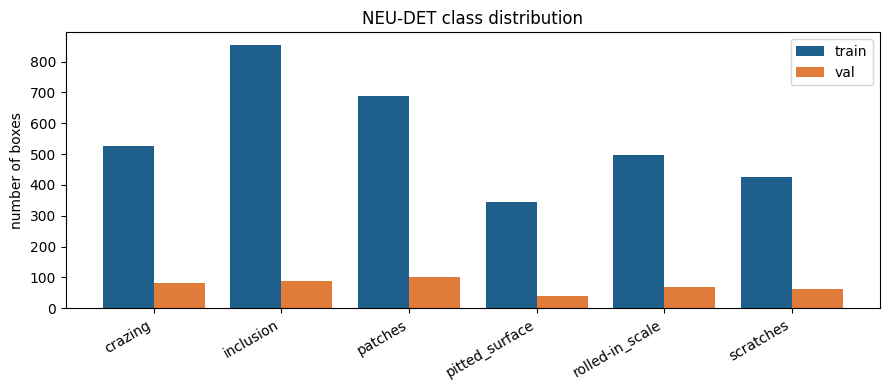

In [3]:
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(CLASSES))
ax.bar(x-0.2, [train_counts[i] for i in range(6)], 0.4, label='train', color='#1f5f8b')
ax.bar(x+0.2, [val_counts[i] for i in range(6)], 0.4, label='val', color='#e07b39')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('number of boxes'); ax.set_title('NEU-DET class distribution')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Sample images per class
Show one example image for each defect type with its bounding boxes.

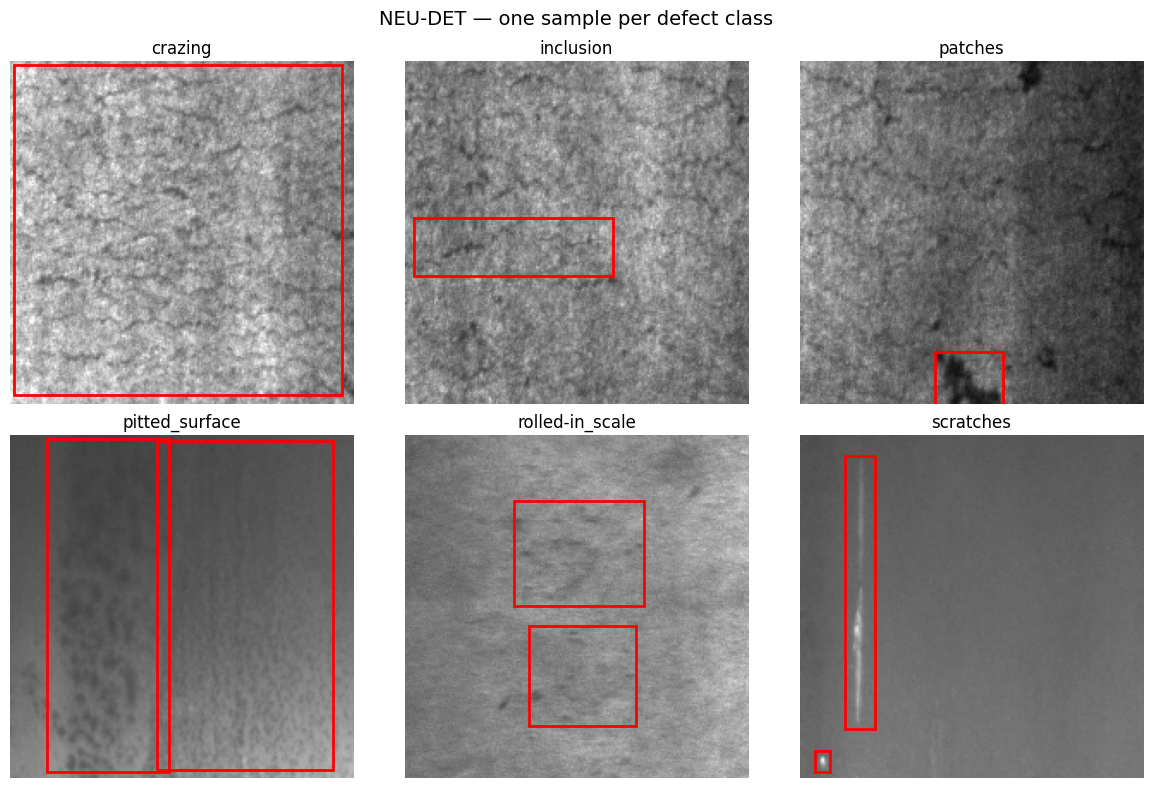

In [4]:
def find_example(class_id, split='train'):
    for txt in (OUT / f'labels/{split}').glob('*.txt'):
        ids = [int(l.split()[0]) for l in txt.read_text().splitlines() if l.strip()]
        if class_id in ids:
            for ext in ['.jpg','.png','.jpeg','.bmp']:
                img = OUT / f'images/{split}' / (txt.stem + ext)
                if img.exists():
                    return img, txt
    return None, None

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for class_id, ax in enumerate(axes.flat):
    img_path, txt_path = find_example(class_id)
    if img_path is None:
        ax.axis('off'); continue
    im = Image.open(img_path); W, H = im.size
    ax.imshow(im, cmap='gray')
    for line in txt_path.read_text().splitlines():
        c, xc, yc, bw, bh = map(float, line.split())
        if int(c) == class_id:
            x = (xc-bw/2)*W; y = (yc-bh/2)*H
            ax.add_patch(plt.Rectangle((x,y), bw*W, bh*H,
                          fill=False, edgecolor='red', linewidth=2))
    ax.set_title(CLASSES[class_id]); ax.axis('off')
plt.suptitle('NEU-DET — one sample per defect class', fontsize=14)
plt.tight_layout(); plt.show()

## 4. Bounding-box size distribution
Defect sizes vary a lot — useful to know before choosing image size / anchors.

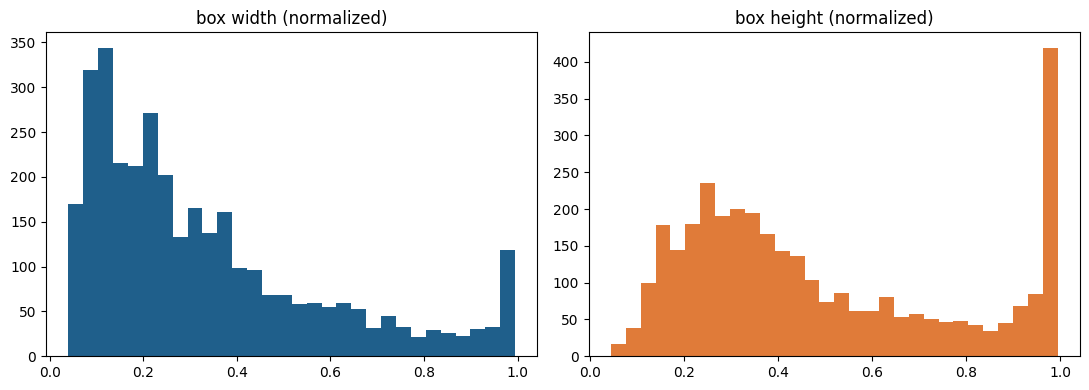

avg box: 0.33 x 0.49 (fraction of image)


In [5]:
widths, heights = [], []
for txt in (OUT / 'labels/train').glob('*.txt'):
    for line in txt.read_text().splitlines():
        if line.strip():
            _, _, _, bw, bh = map(float, line.split())
            widths.append(bw); heights.append(bh)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4))
a1.hist(widths, bins=30, color='#1f5f8b'); a1.set_title('box width (normalized)')
a2.hist(heights, bins=30, color='#e07b39'); a2.set_title('box height (normalized)')
plt.tight_layout(); plt.show()
print(f'avg box: {np.mean(widths):.2f} x {np.mean(heights):.2f} (fraction of image)')

## 5. Feature-activation heatmaps
A quick look at *where* a (COCO-pretrained) YOLOv8n backbone responds on each defect type. We hook
the end-of-backbone feature map, average it over channels, and overlay it on the image. Bright (red)
regions are where the network's features fire strongest — a sanity check that the texture/defect
regions, not the background, drive the representation.

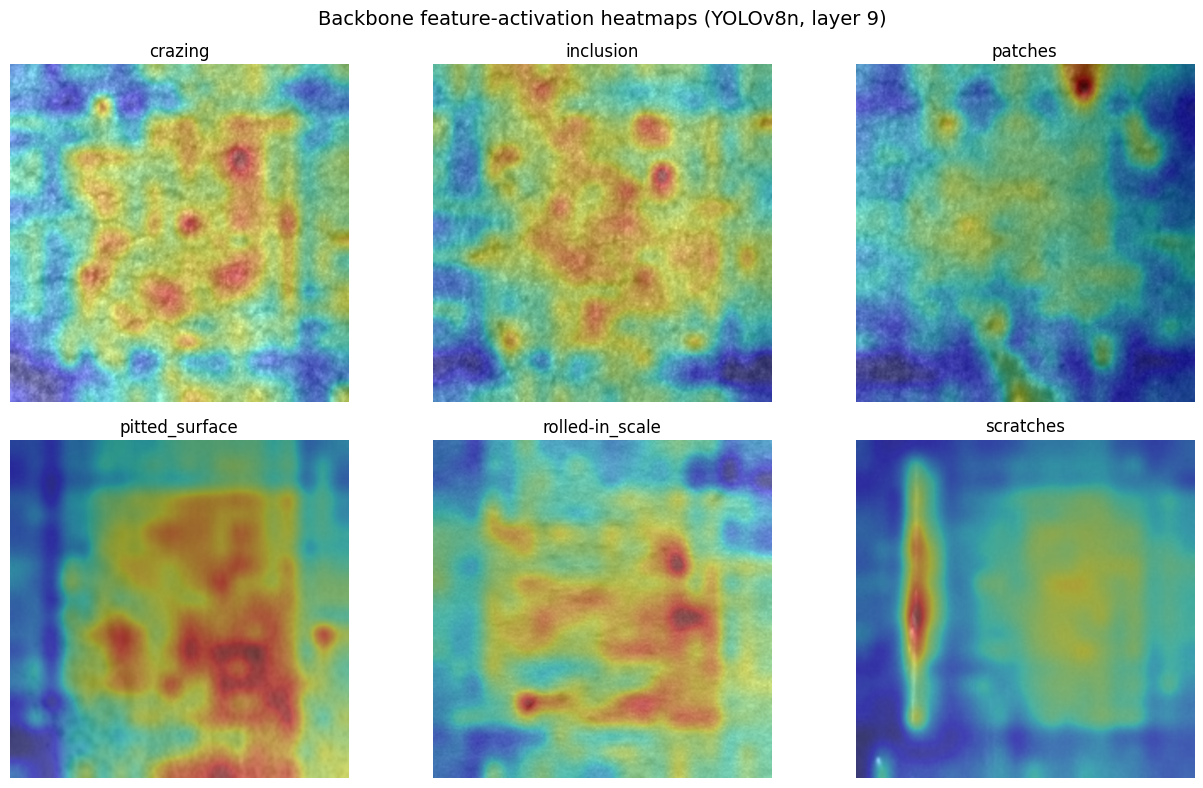

In [6]:
# Feature-activation heatmaps: where a YOLOv8n backbone responds most for each defect type.
import torch
from PIL import Image
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else 'cpu'
ymodel = YOLO(str(ROOT / 'yolov8n.pt'))                  # COCO-pretrained backbone
net = ymodel.model.to(device).eval()

LAYER = 9                                                 # end of backbone (SPPF) -> most semantic
_feat = {}
hook = net.model[LAYER].register_forward_hook(lambda m, i, o: _feat.__setitem__('a', o))

def activation_map(img_path, size=640):
    rgb = np.array(Image.open(img_path).convert('RGB').resize((size, size)))   # PIL (no cv2 needed)
    t = torch.from_numpy(rgb).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    with torch.no_grad():
        net(t)
    a = _feat['a'][0].mean(0).cpu().numpy()               # mean over channels -> (h, w)
    a = (a - a.min()) / (np.ptp(a) + 1e-6)
    heat = np.array(Image.fromarray((a * 255).astype('uint8')).resize((size, size))) / 255.0
    return rgb, heat

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for cid, ax in enumerate(axes.flat):
    p, _ = find_example(cid)
    if p is None:
        ax.axis('off'); continue
    base, heat = activation_map(p)
    ax.imshow(base); ax.imshow(heat, cmap='jet', alpha=0.45)
    ax.set_title(CLASSES[cid]); ax.axis('off')
hook.remove()
plt.suptitle('Backbone feature-activation heatmaps (YOLOv8n, layer 9)', fontsize=14)
plt.tight_layout(); plt.show()

## 6. Feature-vector embeddings (PCA + t-SNE)
Each image is passed through the YOLOv8n backbone and reduced to a single **feature vector**
(global-average-pooled deep features). Projecting those vectors to 2-D shows how separable the
six defect classes are *before* any fine-tuning — tight, well-separated clusters mean the task is
learnable; overlap (e.g. *crazing* vs *rolled-in_scale*) flags the hard classes.

feature matrix: (240, 256)


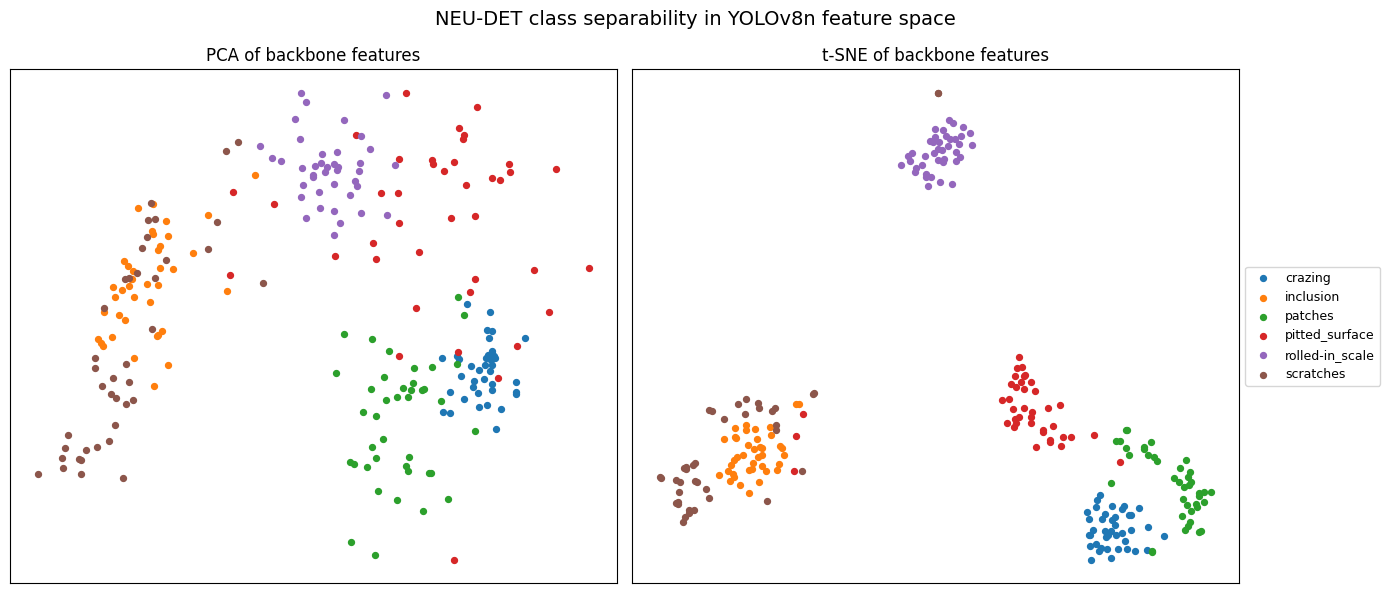

: 

In [ ]:
# Feature-vector embeddings: project deep backbone features to 2D to reveal class separability.
import numpy as np, random
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

N_PER_CLASS = 40                                          # sampled per class (240 imgs total)
_emb = {}
hook = net.model[LAYER].register_forward_hook(lambda m, i, o: _emb.__setitem__('a', o))

def embed(img_path, size=640):
    rgb = np.array(Image.open(img_path).convert('RGB').resize((size, size)))   # PIL (no cv2 needed)
    t = torch.from_numpy(rgb).permute(2, 0, 1).float().unsqueeze(0).to(device) / 255.0
    with torch.no_grad():
        net(t)
    return _emb['a'][0].mean(dim=(1, 2)).cpu().numpy()    # global avg pool -> (C,) feature vector

random.seed(42)
paths, labels = [], []
for cid, name in enumerate(CLASSES):
    files = sorted((OUT / 'images/train').glob(f'{name}_*.jpg'))
    for p in random.sample(files, min(N_PER_CLASS, len(files))):
        paths.append(p); labels.append(cid)

X = np.stack([embed(p) for p in paths]); y = np.array(labels)
hook.remove()
print('feature matrix:', X.shape)

pca  = PCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=42).fit_transform(X)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
for cid, name in enumerate(CLASSES):
    m = y == cid
    a1.scatter(pca[m, 0], pca[m, 1], s=18, label=name)
    a2.scatter(tsne[m, 0], tsne[m, 1], s=18, label=name)
a1.set_title('PCA of backbone features'); a2.set_title('t-SNE of backbone features')
for a in (a1, a2): a.set_xticks([]); a.set_yticks([])
a2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.suptitle('NEU-DET class separability in YOLOv8n feature space', fontsize=14)
plt.tight_layout(); plt.show()

✅ **EDA complete.** Next: open `03_train_baseline.ipynb`.